In [1]:
from la_forge import core as co
from la_forge import diagnostics as dg
import os
import h5py
import json
import matplotlib.pyplot as plt
from math import ceil

plt.rcParams['figure.max_open_warning'] = 100


# QUICK PLOT

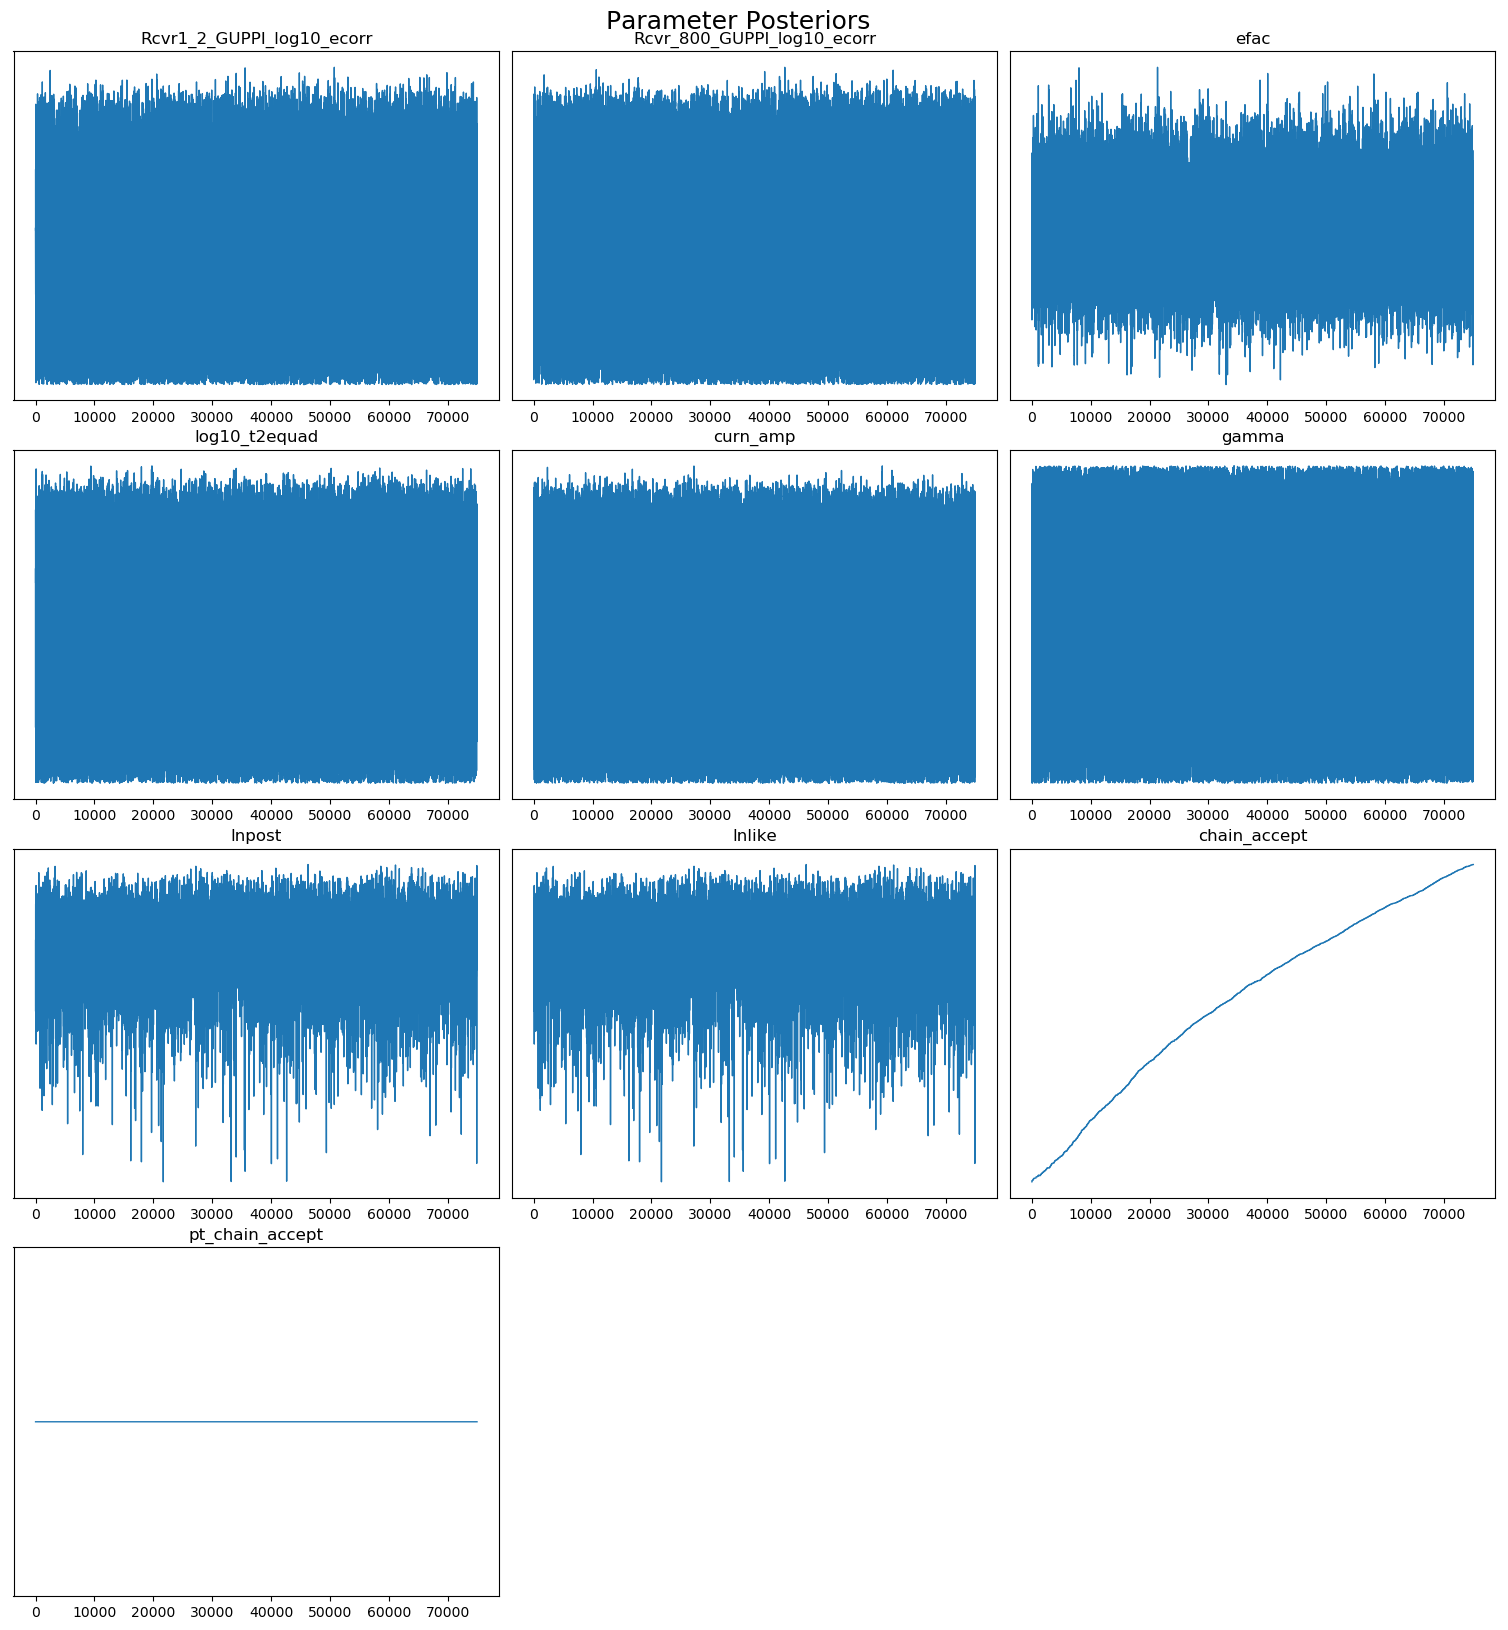

In [4]:
params = ["J1843-1113_Rcvr1_2_GUPPI_log10_ecorr","J1843-1113_Rcvr_800_GUPPI_log10_ecorr","J1843-1113_efac","J1843-1113_log10_t2equad","curn_amp","gamma"]
dir = "/home/mitch/test_quick_burst/15_year_data/15_year_CURN_run/J1843-1113/"
core = co.Core(chaindir=dir,label="J1843-1113",params=params)
dg.plot_chains(core, hist=False)

# Get data from both enterpise and quickburst if it exists

In [35]:
#Enterprise
enterprise_chains_dir = '/home/mitch/test_quick_burst/enterprise/chains/'
psr_files = []
psr_names = []
ent_params=['efac','equad']
with open('Psr_names.txt','r') as file:
    for line in file:
        psr_names.append(line.strip())
        psr_files.append(enterprise_chains_dir+line.strip())

core_arr = [co.Core(chaindir=(enterprise_chains_dir+core),label=core,params=ent_params) for core in psr_names]


In [36]:
#QuickBurst
quickburst_h5df = "/home/mitch/test_quick_burst/quick_burst/20_simple_psrs_data/20_simple_psrs_run.h5df"

if os.path.exists(quickburst_h5df):
    with h5py.File(quickburst_h5df, 'r+') as f:
        chain_samples = f['samples_cold'][()]
        log_likelihood = f['log_likelihood'][()]
        acc_frac = f['acc_fraction'][()]
        param_names = f['par_names'][()]

    param_names = [name.decode('utf-8') for name in param_names]


In [37]:
#psrs parameters
noise_dict_dir = "/home/mitch/test_quick_burst/20_pulsars/WN_only/noise_dict.json"

with open(noise_dict_dir, 'r') as file:
    noise_dict = json.load(file)


# Plots results

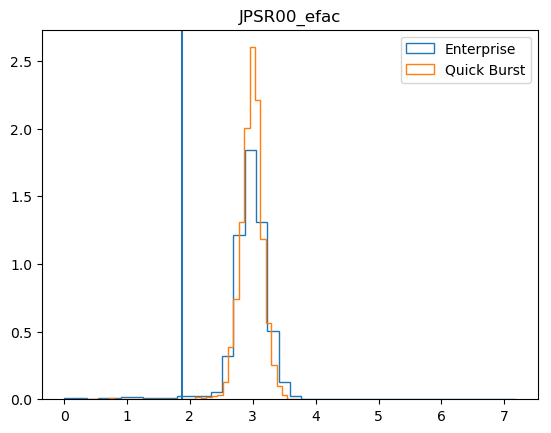

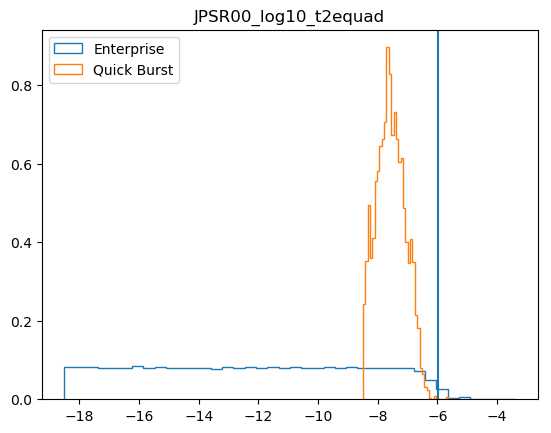

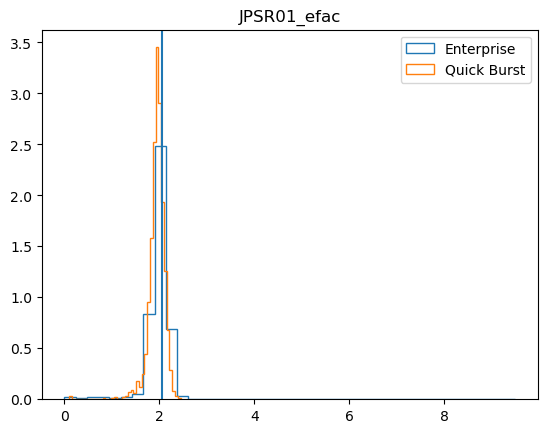

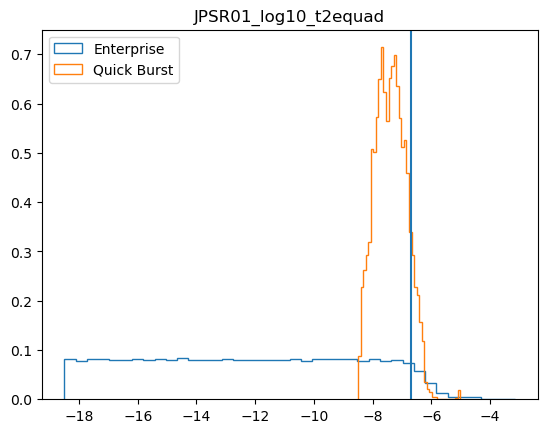

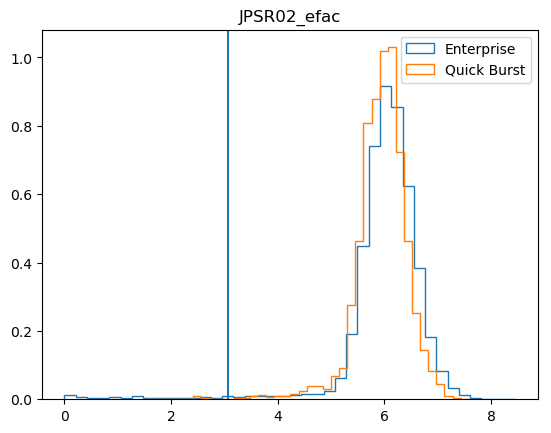

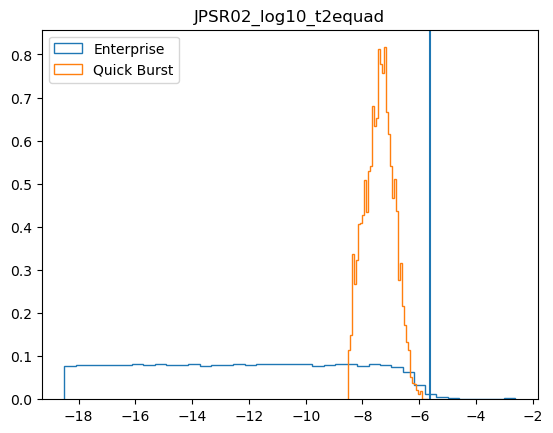

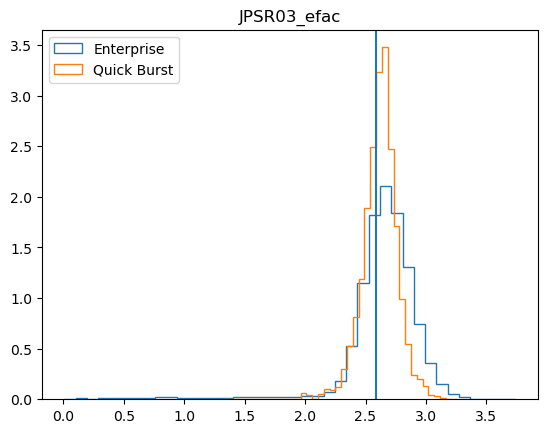

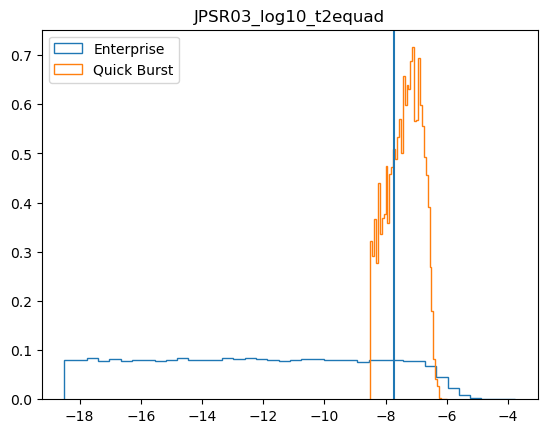

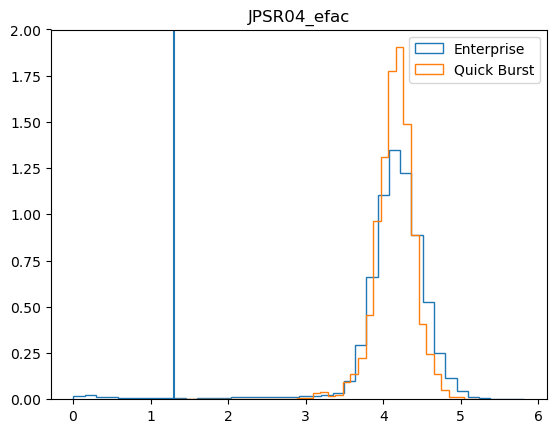

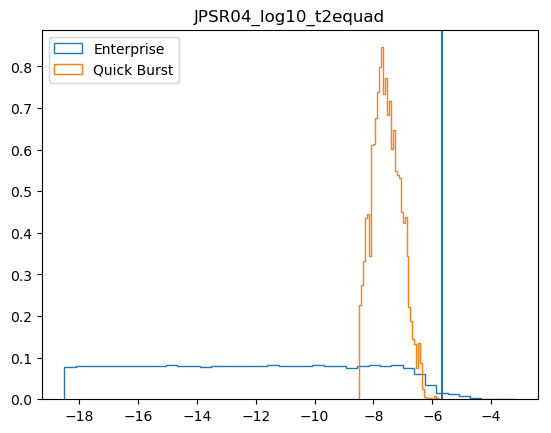

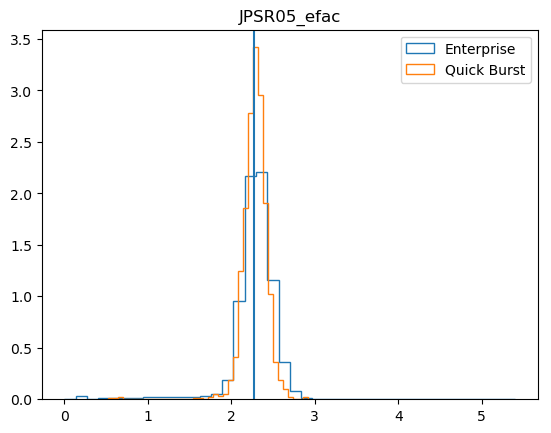

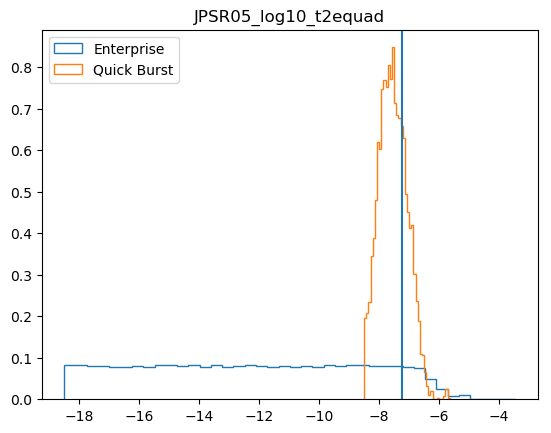

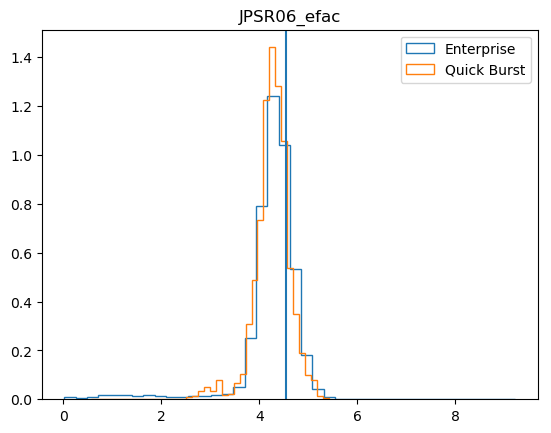

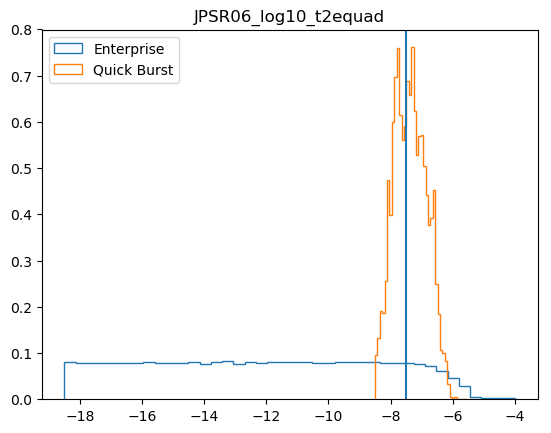

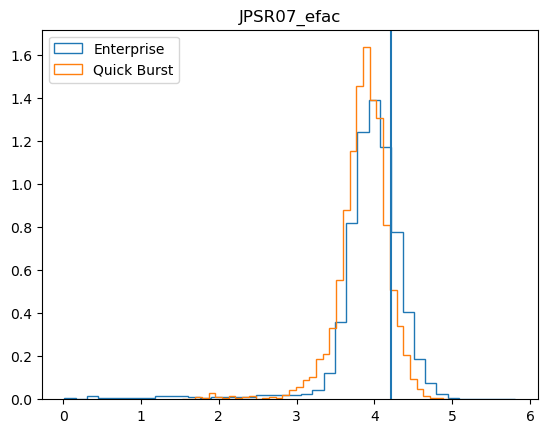

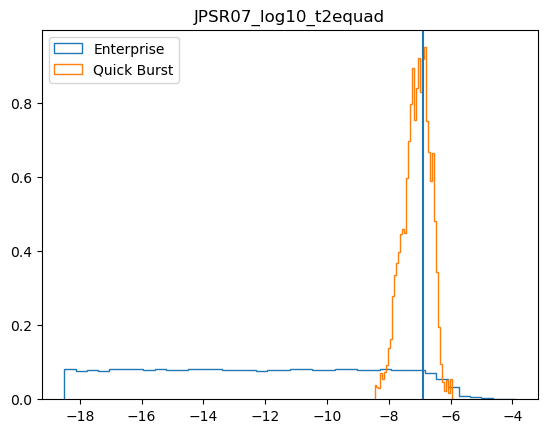

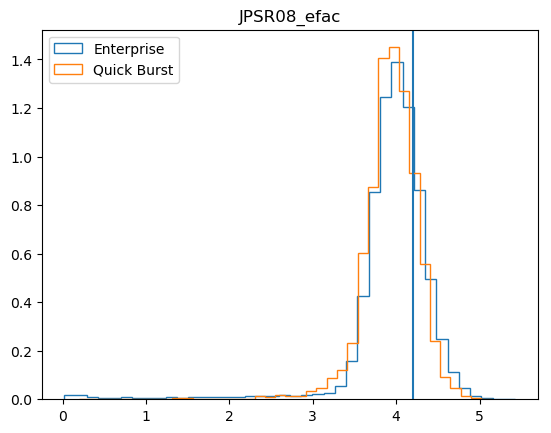

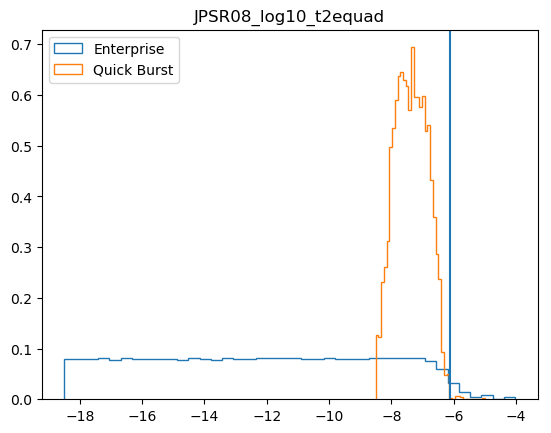

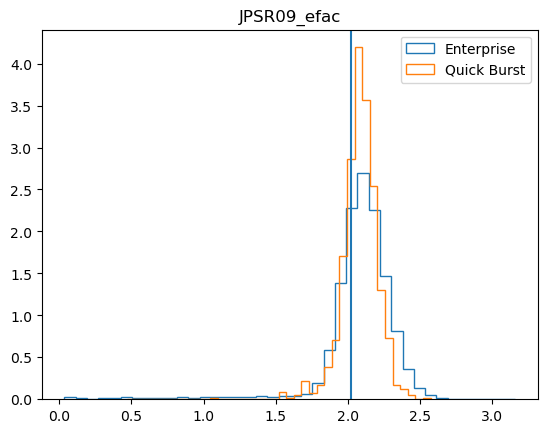

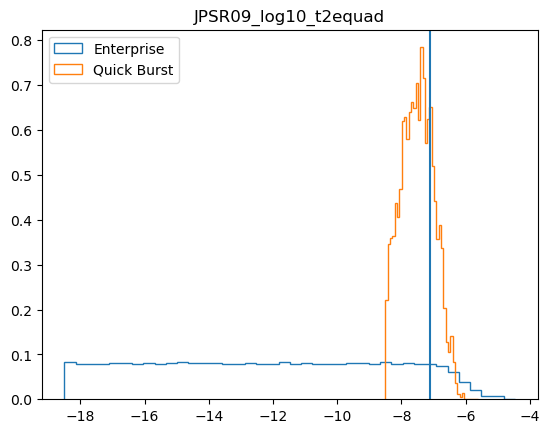

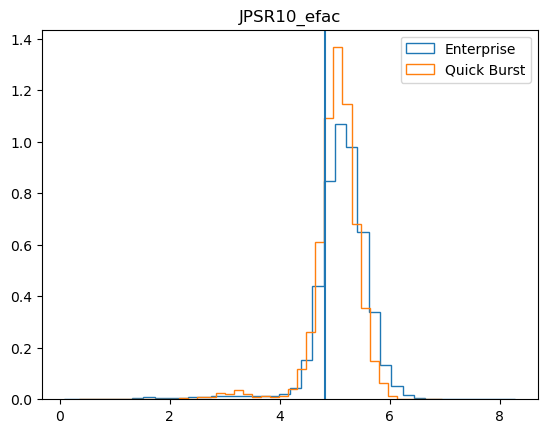

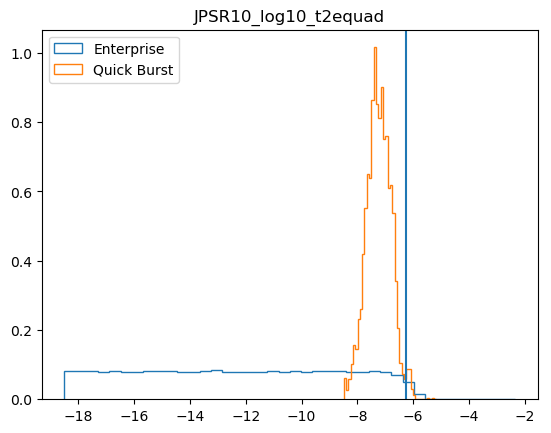

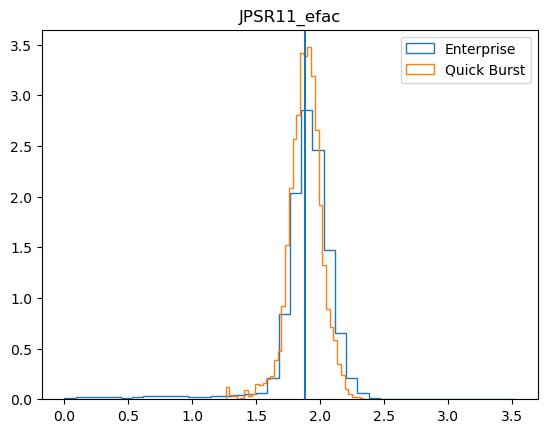

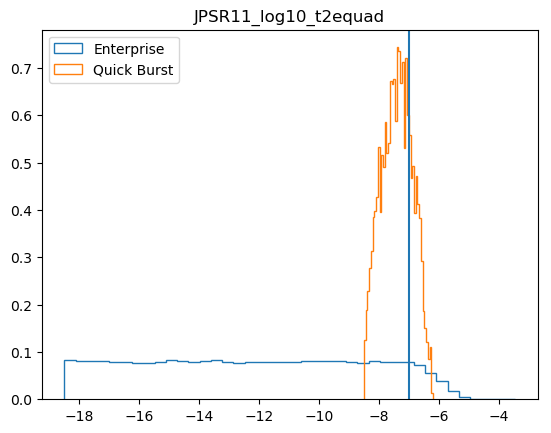

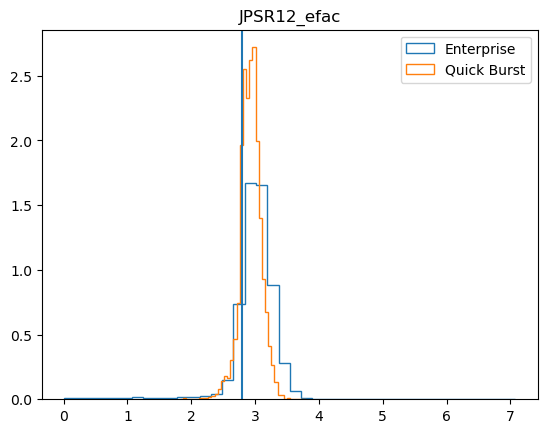

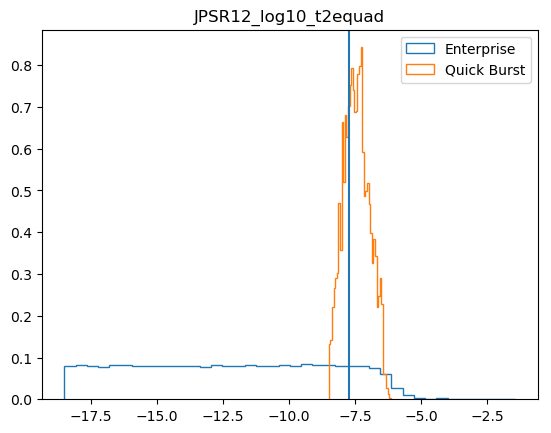

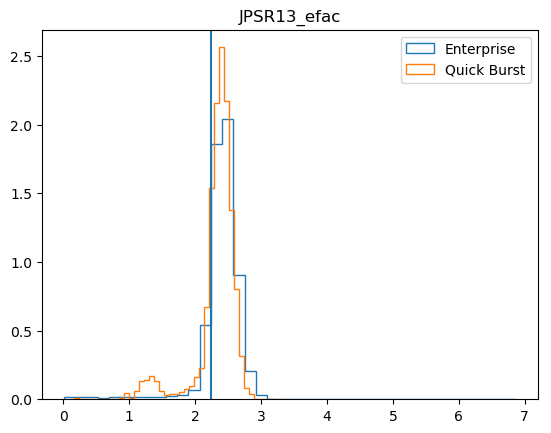

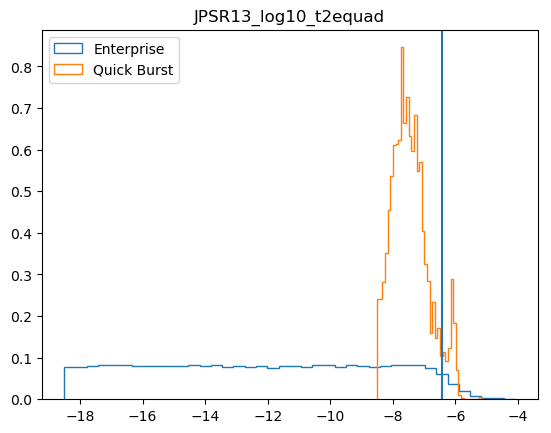

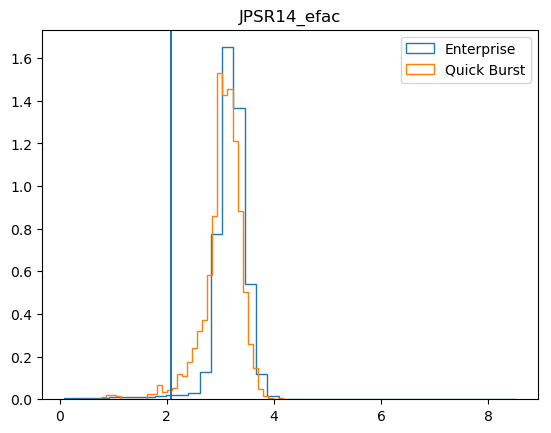

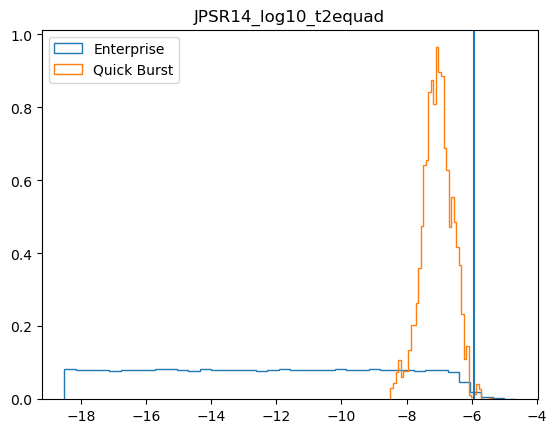

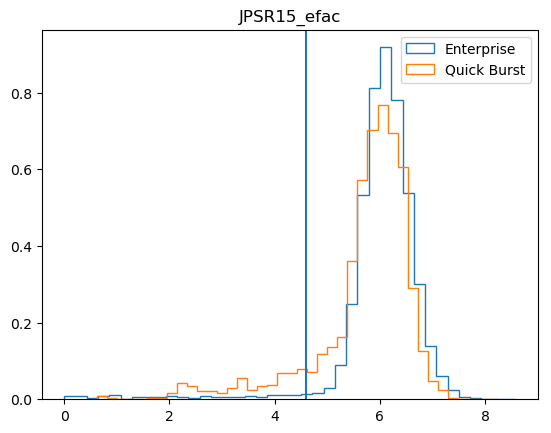

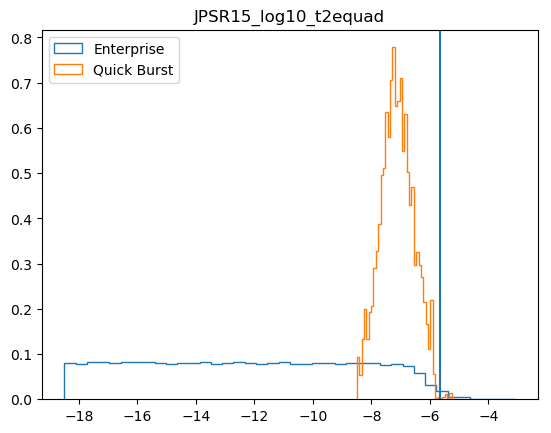

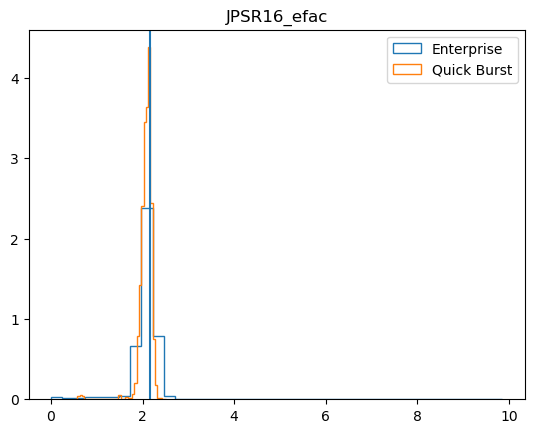

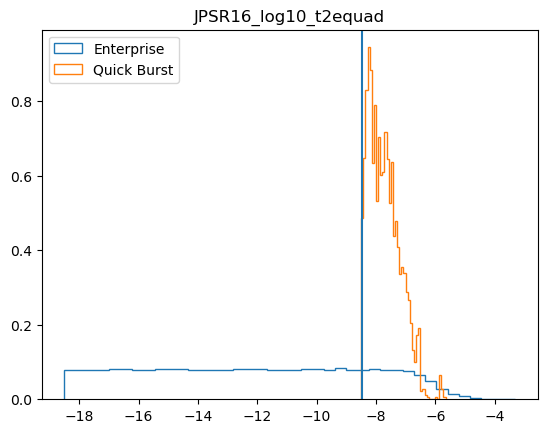

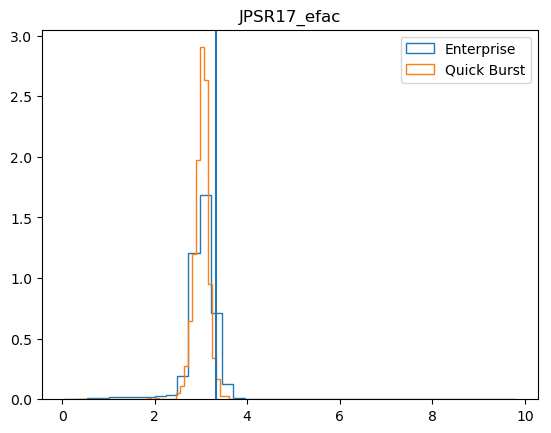

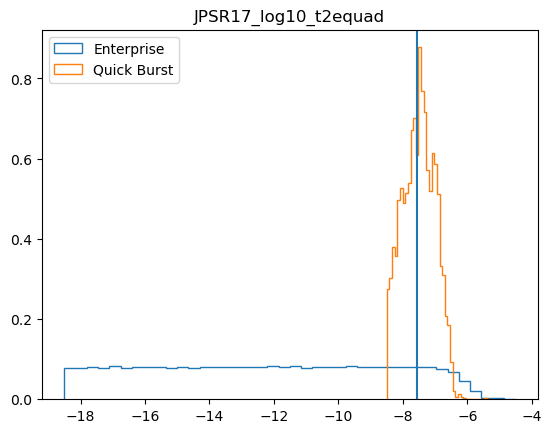

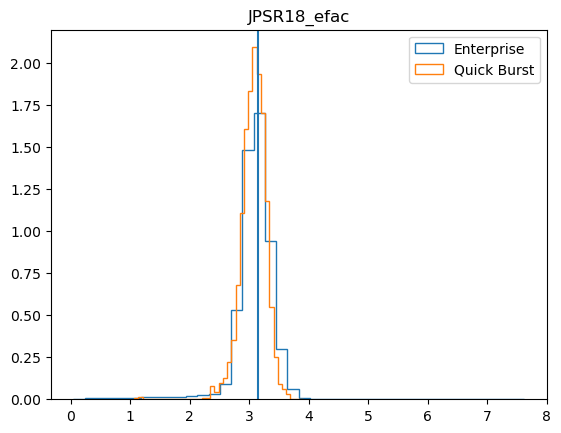

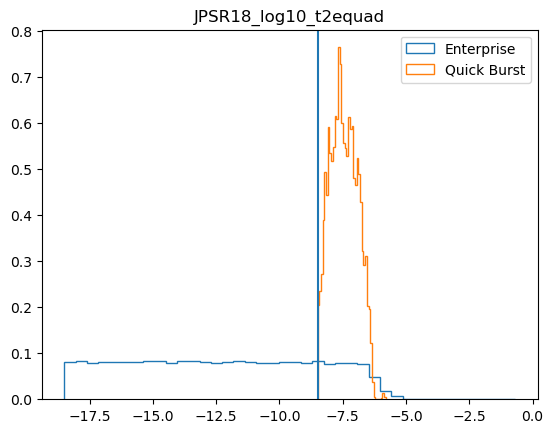

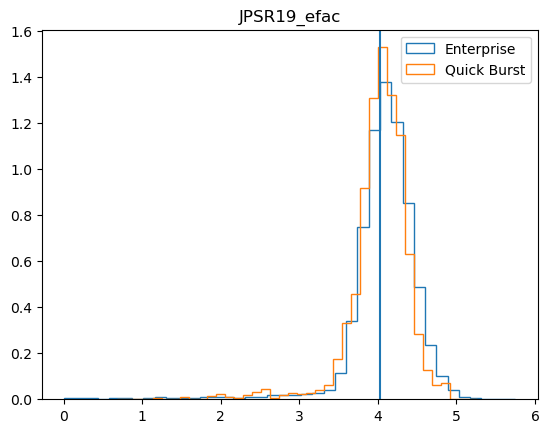

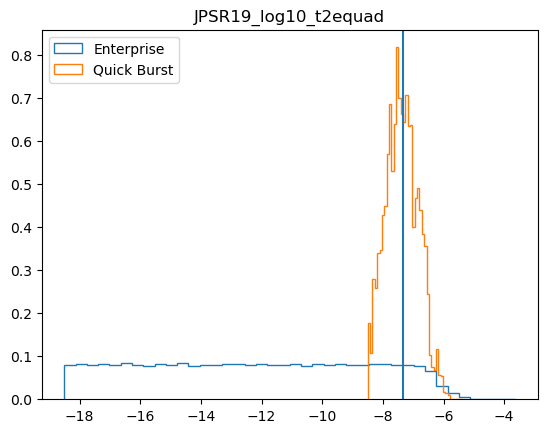

In [38]:
num_psrs = len(core_arr)
num_params = 2
burn_in_precent = 0.1

for i in range(0,num_psrs):
    #plot efac
    plt.figure()
    plt.title(param_names[i*num_params])
    #enerprise histo
    ent_burn = ceil(core_arr[i].chain[:,0].shape[0]*burn_in_precent)
    plt.hist(core_arr[i].chain[:,0],label='Enterprise',density=True,bins=40,histtype='step')
    #quick burst histo
    qb_burn = ceil(chain_samples[0,:,i*2+2].shape[0]*burn_in_precent)
    plt.hist(chain_samples[0,qb_burn:,i*2+2],label='Quick Burst',density=True,bins=40,histtype='step')
    #plot correct value
    plt.axvline(noise_dict[param_names[i*num_params]])
    plt.legend()

    #plot equad
    plt.figure()
    plt.title(param_names[i*num_params+1])
    #enerprise histo
    ent_burn = ceil(core_arr[i].chain[:,1].shape[0]*burn_in_precent)
    plt.hist(core_arr[i].chain[:,1],label='Enterprise',density=True,bins=40,histtype='step')
    #quick burst histo
    qb_burn = ceil(chain_samples[0,:,i*2+3].shape[0]*burn_in_precent)
    plt.hist(chain_samples[0,qb_burn:,i*2+3],label='Quick Burst',density=True,bins=40,histtype='step')
    plt.axvline(noise_dict[param_names[i*num_params+1]])
    plt.legend()
